# F1 – Group 2 Project
## EDA: Pit Stop Performance — Monza 2023–2025

Three EDA questions are answered, plus one storytelling chart:
1. How does pit lane time vary by team?
2. How does it vary by year (was Monza getting faster or slower)?
3. What does a normal pit stop look like vs the outliers?
4. Storytelling: which team has the fastest pit crew at Monza?


In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

print("Imports done!")


Imports done!


## 1. Load pit timing data

In [2]:
pit_df = pd.read_csv("../data/csv/pit_with_compound.csv")
print(f"Loaded: {len(pit_df)} pit stops across {pit_df['year'].nunique()} years")
pit_df.head()


Loaded: 74 pit stops across 3 years


,date,session_key,stop_duration,meeting_key,lap_number,driver_number,pit_duration,lane_duration,year,stint_lap_start,lap_start,compound,stint_number,name_acronym,full_name,team_name
0,2023-09-03T13:38:35.432000+00:00,9157,NaN,1218,10,10,27.3,27.3,2023,11,11.0,HARD,2,GAS,Pierre GASLY,Alpine
1,2023-09-03T13:39:58.556000+00:00,9157,NaN,1218,11,24,24.3,24.3,2023,12,12.0,HARD,2,ZHO,ZHOU Guanyu,Alfa Romeo
2,2023-09-03T13:41:37.664000+00:00,9157,NaN,1218,12,20,24.6,24.6,2023,13,13.0,MEDIUM,2,MAG,Kevin MAGNUSSEN,Haas F1 Team
3,2023-09-03T13:42:51.944000+00:00,9157,NaN,1218,13,40,24.2,24.2,2023,14,14.0,HARD,2,LAW,Liam LAWSON,AlphaTauri
4,2023-09-03T13:44:22.740000+00:00,9157,NaN,1218,14,2,24.7,24.7,2023,15,15.0,HARD,2,SAR,Logan SARGEANT,Williams


## 2. Data  check

In [3]:
# How many pit stops per year — is the dataset balanced?
# (2024 had more stops than 2023/2025, suggesting more two-stoppers that year.)
print("Pit stops per year:")
print(pit_df['year'].value_counts().sort_index())
print()

print("Field availability:")
print(pit_df[['pit_duration', 'lane_duration']].notna().sum())


Pit stops per year:
year
2023    25
2024    30
2025    19
Name: count, dtype: int64

Field availability:
pit_duration     74
lane_duration    74
dtype: int64


In [4]:
# Check if pit_duration and lane_duration are actually identical row-by-row
identical = (pit_df['pit_duration'] == pit_df['lane_duration']).all()
print(f"Identical in every row? {identical}")

# Show any rows where they differ (empty table = they're the same everywhere)
diffs = pit_df[pit_df['pit_duration'] != pit_df['lane_duration']]
print(f"Number of rows where they differ: {len(diffs)}")
if len(diffs) > 0:
    print("\nRows with differences:")
    print(diffs[['year', 'name_acronym', 'pit_duration', 'lane_duration']])

Identical in every row? True
Number of rows where they differ: 0


## 3. Pandas EDA — pit duration distribution

In [5]:
# Overall distribution of pit lane time across all 74 stops, all years.
print("Pit duration (seconds) — all stops, 2023–2025:")
pit_df['pit_duration'].describe().round(2)


Pit duration (seconds) — all stops, 2023–2025:


count    74.00
mean     25.65
std       3.08
min      23.60
25%      24.20
50%      24.60
75%      25.19
max      38.80
Name: pit_duration, dtype: float64

In [6]:
# Per-year summary — has Monza pit lane time gotten faster or slower?
print("Pit duration by year:")
pit_df.groupby('year')['pit_duration'].agg(
    n_stops='count',
    mean='mean',
    median='median',
    fastest='min',
    slowest='max',
).round(2)


Pit duration by year:


,n_stops,mean,median,fastest,slowest
year,,,,,
2023,25,24.93,24.50,23.7,31.70
2024,30,26.10,24.65,23.7,38.80
2025,19,25.88,24.92,23.6,38.42


In [7]:
# Per-team summary — sorted by median( the mean gets distorted by one bad pit stop, and the median doesn't.)
team_perf = (
    pit_df.groupby('team_name')['pit_duration']
          .agg(n_stops='count', median='median', mean='mean', std='std', fastest='min')
          .round(2)
          .sort_values('median')
)
print("Team pit lane performance (sorted by median, fastest first):")
team_perf


Team pit lane performance (sorted by median, fastest first):


,n_stops,median,mean,std,fastest
team_name,,,,,
McLaren,9,24.10,25.31,2.68,23.60
AlphaTauri,2,24.20,24.20,0.00,24.20
Racing Bulls,2,24.24,24.24,0.12,24.16
Ferrari,6,24.27,24.33,0.43,23.90
Red Bull Racing,8,24.29,24.73,1.39,23.80
Alpine,8,24.45,24.84,1.06,24.10
Alfa Romeo,3,24.60,24.93,0.85,24.30
Mercedes,8,24.66,25.70,2.87,24.10
Williams,6,24.71,24.74,0.21,24.50


In [8]:
# Slowest pit stops
print("Top 10 slowest pit stops:")
(pit_df.nlargest(10, 'pit_duration')
       [['year', 'name_acronym', 'team_name', 'lap_number', 'compound', 'pit_duration']]
       .reset_index(drop=True))


Top 10 slowest pit stops:


,year,name_acronym,team_name,lap_number,compound,pit_duration
0,2024,HUL,Haas F1 Team,5,HARD,38.800
1,2025,STR,Aston Martin,49,SOFT,38.418
2,2024,HUL,Haas F1 Team,32,HARD,36.500
3,2024,RUS,Mercedes,11,HARD,32.600
4,2023,PIA,McLaren,41,MEDIUM,31.700
5,2025,OCO,Haas F1 Team,51,SOFT,30.754
6,2024,RIC,RB,11,HARD,30.300
7,2024,VER,Red Bull Racing,22,HARD,28.100
8,2025,NOR,McLaren,46,SOFT,27.498
9,2023,GAS,Alpine,10,HARD,27.300


## 4. DuckDB EDA


In [9]:
# Common Table Expression pattern: aggregate per team, then compute the gap between worst and median.
# A small gap = consistent team. A large gap = one bad stop ruined their average.
duckdb.query("""
    WITH team_stats AS (
        SELECT
            team_name,
            COUNT(*) AS n_stops,
            ROUND(MEDIAN(pit_duration), 2) AS median_s,
            ROUND(MIN(pit_duration), 2)    AS fastest_s,
            ROUND(MAX(pit_duration), 2)    AS slowest_s
        FROM pit_df
        GROUP BY team_name
        HAVING COUNT(*) >= 3   -- exclude teams with too few stops to compare
    )
    SELECT
        team_name,
        n_stops,
        fastest_s,
        median_s,
        slowest_s,
        ROUND(slowest_s - median_s, 2) AS worst_vs_median_gap
    FROM team_stats
    ORDER BY median_s ASC
""").df()


,team_name,n_stops,fastest_s,median_s,slowest_s,worst_vs_median_gap
0,McLaren,9,23.6,24.10,31.70,7.60
1,Ferrari,6,23.9,24.27,25.10,0.83
2,Red Bull Racing,8,23.8,24.29,28.10,3.81
3,Alpine,8,24.1,24.45,27.30,2.85
4,Alfa Romeo,3,24.3,24.60,25.90,1.30
5,Mercedes,8,24.1,24.66,32.60,7.94
6,Williams,6,24.5,24.71,25.10,0.39
7,Aston Martin,9,24.2,24.90,38.42,13.52
8,Haas F1 Team,9,24.3,25.60,38.80,13.20
9,Kick Sauber,3,24.4,26.14,27.10,0.96


In [10]:
# When in the race do drivers tend to pit?
# Grouping by the compound fitted at the stop reveals strategy timing:
#   HARD  fitted EARLY (drivers undercut to a long stint on the hard tyre)
#   MEDIUM fitted LATER (typical second-stint compound after a HARD opener)
#   SOFT  fitted VERY LATE (only used as a short final-stint sprint to the flag)
duckdb.query("""
    SELECT
        compound,
        COUNT(*) AS n_stops,
        ROUND(AVG(lap_number), 1) AS avg_pit_lap,
        ROUND(MEDIAN(lap_number), 1) AS median_pit_lap,
        MIN(lap_number) AS earliest,
        MAX(lap_number) AS latest
    FROM pit_df
    GROUP BY compound
    ORDER BY avg_pit_lap
""").df()


,compound,n_stops,avg_pit_lap,median_pit_lap,earliest,latest
0,HARD,52,20.9,19.5,5,38
1,MEDIUM,16,32.7,33.0,12,41
2,SOFT,6,48.3,49.0,45,51


## 5. Storytelling chart — Team pit-crew speed

Median is used instead of mean because one
bad stop (e.g. Haas 2024 at 38.8s) ruins a mean and hides true consistency.
Teams with fewer than 3 stops are exclude


In [11]:
# Same colour constants as the strategy chart in EDA_storytelling_Indira.ipynb
GRAY_1 = "#D9D9D9"   # de-emphasised bars
GRAY_2 = "#888888"   # axis ticks
GRAY_3 = "#3A3A3A"   # text
BLUE_1 = "#1F6F8B"   # accent colour


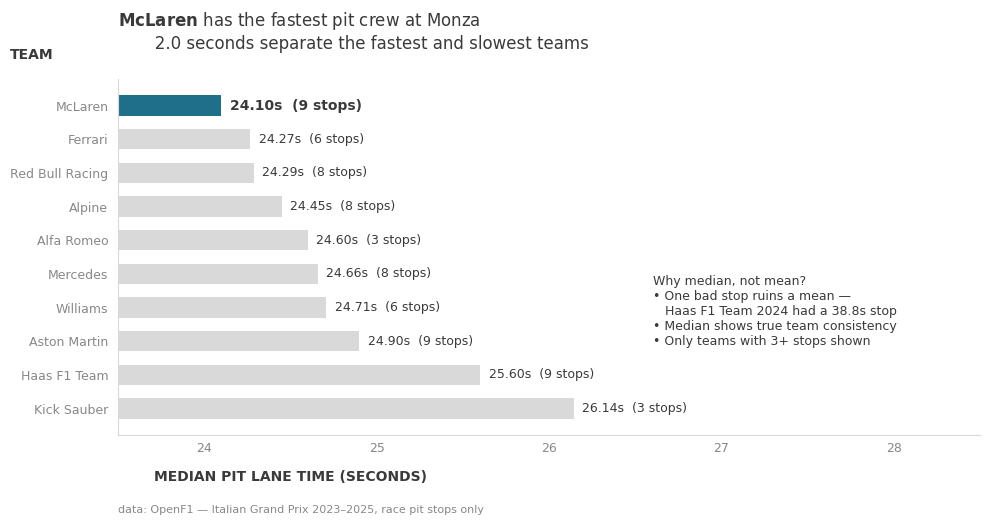

In [ ]:
plt.rcdefaults()

# Ensure output dir exists relative to the notebook.
from pathlib import Path
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Aggregate: median pit-lane time per team, only teams with >= 3 stops.
team_perf = (
    pit_df.groupby("team_name")["pit_duration"]
          .agg(n_stops="count", median="median", slowest="max")
          .query("n_stops >= 3")
          .sort_values("median", ascending=True)
)

# Highlight the fastest team (top of the sorted list).
fastest_team = team_perf.index[0]
colors = [GRAY_1] * len(team_perf)
colors[0] = BLUE_1

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(team_perf.index, team_perf["median"], color=colors, height=0.6)

# Fastest bar on top
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRAY_1)
ax.tick_params(axis="both", labelsize=9, colors=GRAY_2, length=0, pad=5)
ax.tick_params(axis="y", pad=7)

# Wider x-axis so the 'Why?' annotation has room on the right
ax.set_xlim(23.5, 28.5)

ax.set_xlabel("MEDIAN PIT LANE TIME (SECONDS)", color=GRAY_3, fontweight="bold")
ax.set_ylabel("TEAM", rotation=0, color=GRAY_3, fontweight="bold")
ax.xaxis.set_label_coords(0.20, -0.10)
ax.yaxis.set_label_coords(-0.10, 1.05)

# Headline title — names the winner and the gap to slowest
fastest_median = team_perf["median"].iloc[0]
slowest_median = team_perf["median"].iloc[-1]
gap = slowest_median - fastest_median
ax.set_title(
    r"$\bf{" + fastest_team.replace(" ", r"\ ") + r"}$ has the fastest pit crew at Monza"
    + f"\n       {gap:.1f} seconds separate the fastest and slowest teams",
    pad=22, color=GRAY_3, loc="left",
)

# Bar labels: median time + stop count
for i, (team, row) in enumerate(team_perf.iterrows()):
    is_target = (team == fastest_team)
    ax.annotate(
        xy=(row["median"] + 0.05, i),
        text=f"{row['median']:.2f}s  ({int(row['n_stops'])} stops)",
        fontsize=10 if is_target else 9,
        color=GRAY_3,
        fontweight="bold" if is_target else "normal",
        va="center",
    )

# 'Why?' annotation — explains the methodology choice
worst_stop_row = pit_df.loc[pit_df["pit_duration"].idxmax()]
ax.annotate(
    xy=(0.62, 0.45), xycoords="axes fraction",
    text=(
        "Why median, not mean?\n"
        f"• One bad stop ruins a mean —\n"
        f"   {worst_stop_row['team_name']} {int(worst_stop_row['year'])} had a "
        f"{worst_stop_row['pit_duration']:.1f}s stop\n"
        "• Median shows true team consistency\n"
        "• Only teams with 3+ stops shown"
    ),
    fontsize=9, color=GRAY_3, va="top",
)

# Source footer
ax.annotate(
    xy=(0, -0.22), xycoords="axes fraction",
    text="data: OpenF1 — Italian Grand Prix 2023–2025, race pit stops only",
    fontsize=8, color=GRAY_2,
)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pitstops_team_speed.png", dpi=150, bbox_inches="tight")
plt.show()
